# Gaussian Mixture Models for Population Segmentation
This notebook demonstrates how to use Gaussian Mixture Models (GMM) for population segmentation. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
try:
    data = pd.read_csv('population_segmentation.csv')
except FileNotFoundError:
    print('Error loading dataset')
    exit()

print('First 5 rows of the dataset:')
print(data.head())

First 5 rows of the dataset:
         Age  Annual_Income  Spending_Score
0  53.922873   51866.534971       48.196729
1  32.230394  117192.836025       88.016803
2  27.255799   48756.935617       61.940900
3  20.655747   45933.833822       49.037249
4  26.071046   47965.506290       67.326401


## Data Preprocessing
Before applying GMM, it's often beneficial to scale the data, especially when features have different units or scales. This helps ensure that all features contribute equally to the distance calculations.

In [2]:
# Scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

print('First 5 rows of the scaled dataset:')
print(scaled_df.head())

First 5 rows of the scaled dataset:
        Age  Annual_Income  Spending_Score
0  0.626826      -0.603604       -0.460592
1 -0.634712       1.331972        1.233153
2 -0.924012      -0.695739        0.124016
3 -1.307842      -0.779386       -0.424841
4 -0.992912      -0.719189        0.353088


## Determining the Optimal Number of Components (Clusters)
One of the challenges in GMM is determining the optimal number of Gaussian components (clusters). We can use information criteria like the Bayesian Information Criterion (BIC) or Akaike Information Criterion (AIC) to help with this. Lower BIC/AIC values generally indicate a better model.

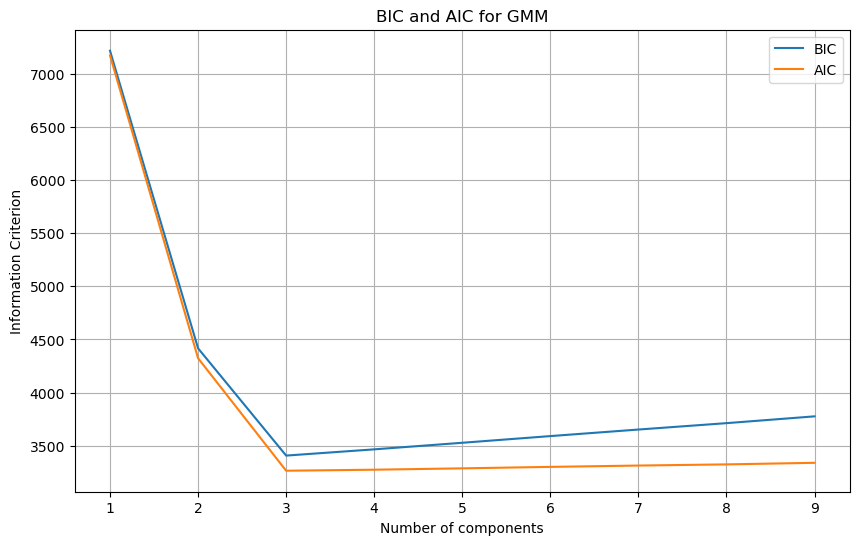

In [3]:
n_components = np.arange(1, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(scaled_data) for n in n_components]

plt.figure(figsize=(10, 6))
plt.plot(n_components, [m.bic(scaled_data) for m in models], label='BIC')
plt.plot(n_components, [m.aic(scaled_data) for m in models], label='AIC')
plt.xlabel('Number of components')
plt.ylabel('Information Criterion')
plt.title('BIC and AIC for GMM')
plt.legend()
plt.grid(True)
plt.savefig('bic_aic_gmm.png')
plt.show()

# Based on the plot, choose the number of components with the lowest BIC/AIC
# For this data, we expect around 3 components.

## Applying Gaussian Mixture Model
Now we apply the GMM with the chosen number of components to segment the population.

In [4]:
# Choose the optimal number of components 
n_clusters = 3  # This can be determined from the BIC/AIC plot
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm.fit(scaled_data)
cluster_labels = gmm.predict(scaled_data)

data['Cluster'] = cluster_labels
scaled_df['Cluster'] = cluster_labels

print('Cluster distribution:')
print(data['Cluster'].value_counts())

Cluster distribution:
Cluster
1    400
0    300
2    300
Name: count, dtype: int64


## Visualizing the Segmentation Results
We can visualize the clusters using scatter plots. Since our data is 3-dimensional, we'll use pairwise scatter plots to observe the separation.

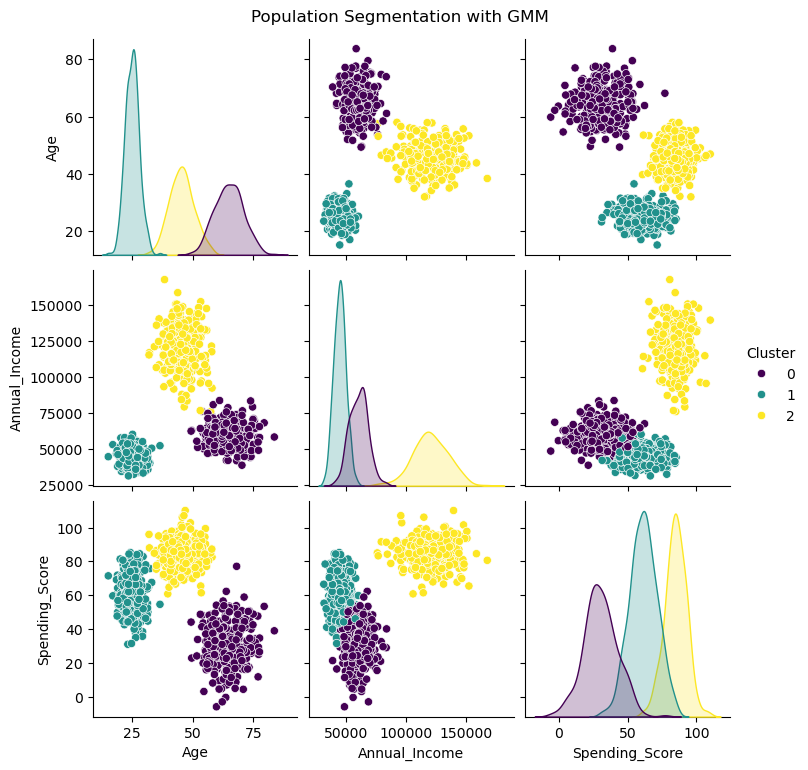

In [5]:
# Pairplot of the data colored by cluster
sns.pairplot(data, hue='Cluster', palette='viridis')
plt.suptitle('Population Segmentation with GMM', y=1.02) # Adjust title position
plt.savefig('gmm_pairplot.png')
plt.show()


## Analyzing Cluster Characteristics
To understand what each segment represents, we can examine the mean values of the original features for each cluster.

In [6]:
cluster_means = data.groupby('Cluster').mean()
print('Mean values for each cluster:')
print(cluster_means)

# Interpretation of clusters based on means
# Cluster 0: (e.g., Young, lower income, moderate spending)
# Cluster 1: (e.g., Middle-aged, high income, high spending)
# Cluster 2: (e.g., Seniors, moderate income, low spending)


Mean values for each cluster:
               Age  Annual_Income  Spending_Score
Cluster                                          
0        64.932655   60407.819767       30.202746
1        25.067646   44808.279029       61.309422
2        45.458594  120642.345589       84.802310
